# Dimensiereductie

Auteurs: Brian van der Bijl (brian.vanderbijl@hu.nl), Tijmen Muller

- Studentnummer: 1884700
- Naam: Malik Ottevanger
- Datum: 06/03/2026

## Deel I: Principal Component Analysis (PCA)

Het _Principal Component Analysis_ (PCA) algoritme kan gebruikt worden om het aantal dimensies van een dataset te reduceren tot de belangrijkste componenten. Als de originele dataset $n$ dimensies heeft, dan kunnen we met onderstaande stappen dit terugbrengen tot een (zelfgekozen) aantal van $n^\prime$ dimensies.

1. Centreer de data.
2. Bereken de covariantie van alle features onderling. 
3. Bereken de Eigenvectors en Eigenvalues van de covariantiematrix.
4. Kies de $n^\prime$ Eigenvectors om de dimensiereductie mee uit te voeren.
5. Vermenigvuldig de $n^\prime$ Eigenvectors met de originele data om de reductie toe te passen.

### Context

Gegeven is een databestand met embeddings van 200 tekstfragmenten. Elke embedding bestaat in 15 dimensies, en is gelabeled met een categorie. We gaan dimensionaliteitsreductie toepassen om de data te kunnen plotten.

De categorie geeft aan in welk genre de tekstfragmenten thuishoren. Daarnaast is onderscheid gemaakt tussen het perspectief waarin het fragment geschreven is: ik (1st person) of hij/haar/hen (3rd person):
- Fantasy (1st person)
- Fantasy (3rd person)
- Science Fiction (1st person)
- Science Fiction (3rd person)
- Romance (1st person)
- Romance (3rd person)
- Crime (1st person)
- Crime (3rd person)

In [26]:
import numpy as np
import pickle
import matplotlib.pyplot as plt

# Show floats on 3 digits, suppress scientific notation
np.set_printoptions(precision=3, suppress=True)

In [27]:
with open('data.pkl', 'rb') as file:
    data = pickle.load(file)

data.sample(5)

e_1,e_2,e_3,e_4,e_5,e_6,e_7,e_8,e_9,e_10,e_11,e_12,e_13,e_14,e_15,label
f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,str
1.75366,1.031907,0.898449,1.118782,0.656212,5.867586,1.140568,0.593038,0.074024,1.397105,0.30324,0.343267,0.957534,0.534475,0.878946,"""Romance (1st person)"""
1.474969,1.014354,1.072624,0.753271,0.647848,3.997754,0.450743,3.132754,1.25369,0.997379,0.582323,1.380116,1.013943,1.052932,0.550524,"""Fantasy (1st person)"""
0.973209,0.904145,0.503891,1.021909,0.549382,4.706039,0.533499,2.294476,1.002988,1.414646,0.851572,0.771699,0.72632,0.918338,0.643601,"""Crime (1st person)"""
0.66742,0.41405,0.27638,1.427912,1.407116,4.864125,1.095754,1.652713,1.019534,0.705374,1.055442,0.989978,1.520906,1.259134,0.353649,"""Romance (3rd person)"""
1.486474,0.833882,1.311363,0.977317,1.001618,3.03429,1.043062,3.130737,1.276281,1.310523,0.539719,0.704375,0.820705,0.568861,0.677814,"""Fantasy (3rd person)"""


### Voorbereidende opdracht

Gegeven een dataset met $m$ datapunten met elk $n$ features en een gewenste reductie tot $n^\prime$ dimensies. Bepaal voor elk van de vijf stappen van het algoritme wat de dimensies (oftewel `shape`) is van de volgende tussenresultaten:

0. De matrix met de originele dataset.
1. De matrix met de gemiddelden per feature om de data mee te centreren.
2. De covariantiematrix.
3. De matrix met de Eigenvectors en de matrix met de Eigenvalues.
4. De matrix met de _geselecteerde_ Eigenvectors.
5. De matrix met de _gereduceerde_ data.

0:
- Hier is de matrix nog origineel met een shape van (m, n)

1:
- Hier neemt de matrix een shape aan van (1, n). De dataset heeft maar 1 gemiddelde per feature

2:
- Hier neemt de matrix de shape aan van (n,n) de covariantiematrix bevat de covarientie tussen elk paar features dus dat maakt n*n

3:
- De eigenvectors hebben shape (n, n) en de eigenvalues hebben shape (n,). Dit komt omdat de eigenvectors worden berekend uit de covariantiematrix.

4:
- De geselecteerde eigenvectors neemt de vorm (n, n') aan omdat het alleen de beste eigenvectors meeneemt

5:
- De gereduceerde data heeft shape (m, n')

### Opdracht 1. Implementatie

Schrijf een eigen implementatie van het PCA-algoritme `compute_pca(X, n_components)` volgens eerdergenoemde stappen van het algoritme. Maak slim gebruik van fucties van `numpy` waar mogelijk, maar zorg wel dat je begrijpt wat je in elke stap doet. De laatste stap is al gegeven in de functiedefinitie hieronder.

Hint: Laat bij stap 3. zien (bijvoorbeeld met een `print()` statement) dat de meest informatieve Eigenvalue al meer dan 50% van de informatie bevat van onze dataset.

#### Input
- `X: numpy.array` - numpy matrix met dimensies $(m, n)$; elke rij is een datapunt in $n$ dimensies
- `n_components: int` - het gewenste aantal dimensies $n^\prime$

#### Output
`X_reduced: numpy.array` - een $(m, n^\prime)$ numpy matrix met de gereduceerde data.

In [ ]:
def compute_pca(X, n_components):
    """
    Parameters
    ----------
    X : numpy.ndarray
        Input data matrix of shape (m, n), where m is the number of samples and n is the number of features.
    n_components : int
        The number of principal components (dimensions) to keep.

    Returns
    -------
    X_reduced : numpy.ndarray
        The data projected onto the top n_components principal components.
    """
    arr = np.array(X)
    
    # Centreer de data
    # Bereken gemiddelde per feature en trek af van elke rij
    gemiddelden = np.mean(arr, axis=0)
    arr_gecentreerd = arr - gemiddelden
    
    # Bereken de covariantiematrix
    # De covariantiematrix geeft de relaties tussen alle features
    cov_matrix = np.cov(arr_gecentreerd, rowvar=False)
    
    # Bereken eigenvectors en eigenvalues
    eigenvalues, eigenvectors = np.linalg.eigh(cov_matrix)
    
    # Toon hoeveel variantie de grootste eigenvalue verklaart
    totale_variantie = np.sum(eigenvalues)
    grootste_eigenvalue = np.max(eigenvalues)
    percentage = (grootste_eigenvalue / totale_variantie) * 100
    print(f"Grootste eigenvalue: {percentage:.2f}%")
    
    # Selecteer de n_components eigenvectors met hoogste eigenvalues
    # Sorteer indices van hoog naar laag op basis van eigenvalue
    gesorteerde_indices = np.flip(np.argsort(eigenvalues))
    
    # Pak de top n_components indices
    top_indices = gesorteerde_indices[:n_components]
    
    # Selecteer de bijbehorende eigenvectors
    n_eigenvectors = eigenvectors[:, top_indices]
    
    # Projecteer de gecentreerde data op de geselecteerde eigenvectors
    return arr_gecentreerd @ n_eigenvectors

#### Test-scenario
Onderstaande code zou de volgende output moeten opleveren (het minteken kan wisselen):

```python
[[ 0.43437323 -0.49820384]
 [ 0.42077249  0.50351448]
 [-0.85514571 -0.00531064]]
 ```

In [29]:
np.random.seed(1)
X = np.random.rand(3, 10)
X_reduced = compute_pca(X, n_components=2)
print(X_reduced)

Grootste eigenvalue: 68.62%
[[ 0.434  0.498]
 [ 0.421 -0.504]
 [-0.855  0.005]]


### Opdracht 2. Visualisatie met dimensiereductie

Maak op basis van de aangeleverde `data` een numpy array van de datapunten, en gebruik je PCA-implementatie om een 2D- en 3D-weergave van de data te maken. Maak van elke weergave een plot, waarbij iedere categorie een eigen kleur krijgt.

Grootste eigenvalue: 50.98%
Grootste eigenvalue: 50.98%


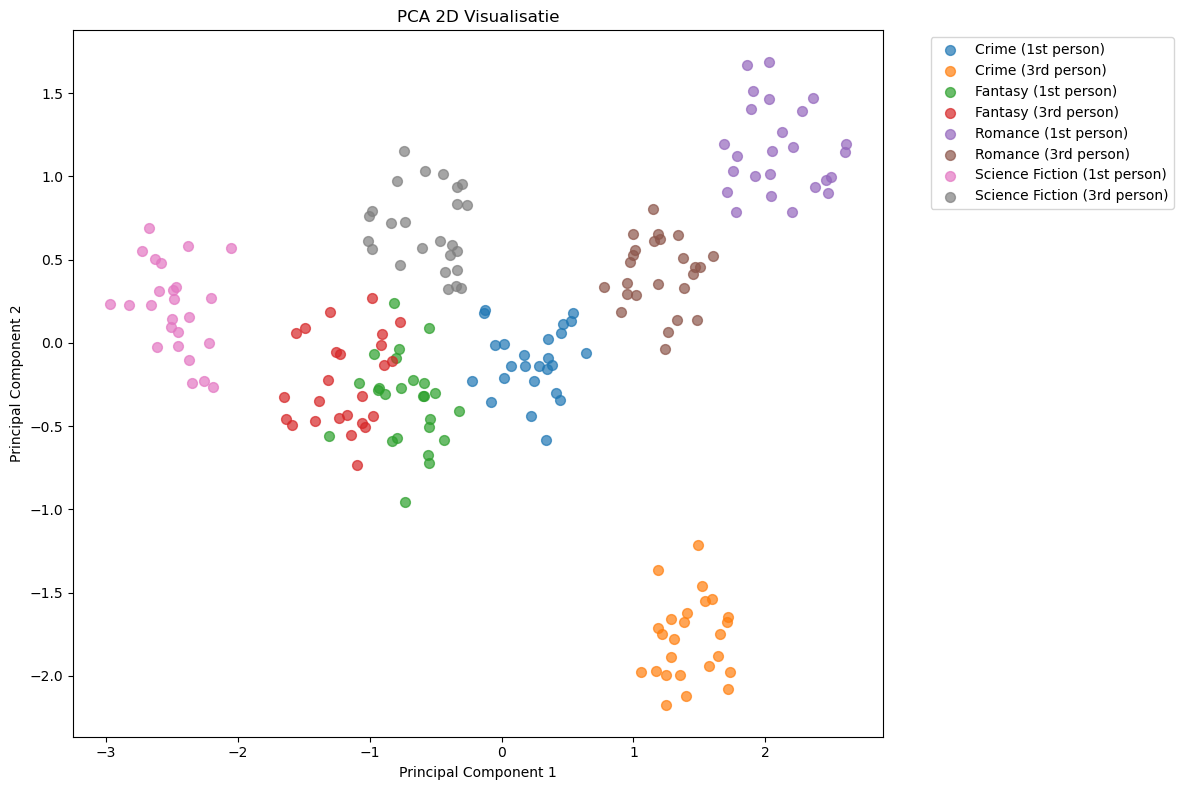

In [ ]:
feature_columns = [col for col in data.columns if col != 'label']
X = data.select(feature_columns).to_numpy()

labels = data['label'].to_numpy()

# 2D reductie
X_2d = compute_pca(X, n_components=2)

# 3D reductie
X_3d = compute_pca(X, n_components=3)

plt.figure(figsize=(12, 8))

for categorie in np.unique(labels):
    mask = labels == categorie
    plt.scatter(X_2d[mask, 0], X_2d[mask, 1], label=categorie, alpha=0.7, s=50)

plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('PCA 2D Visualisatie')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

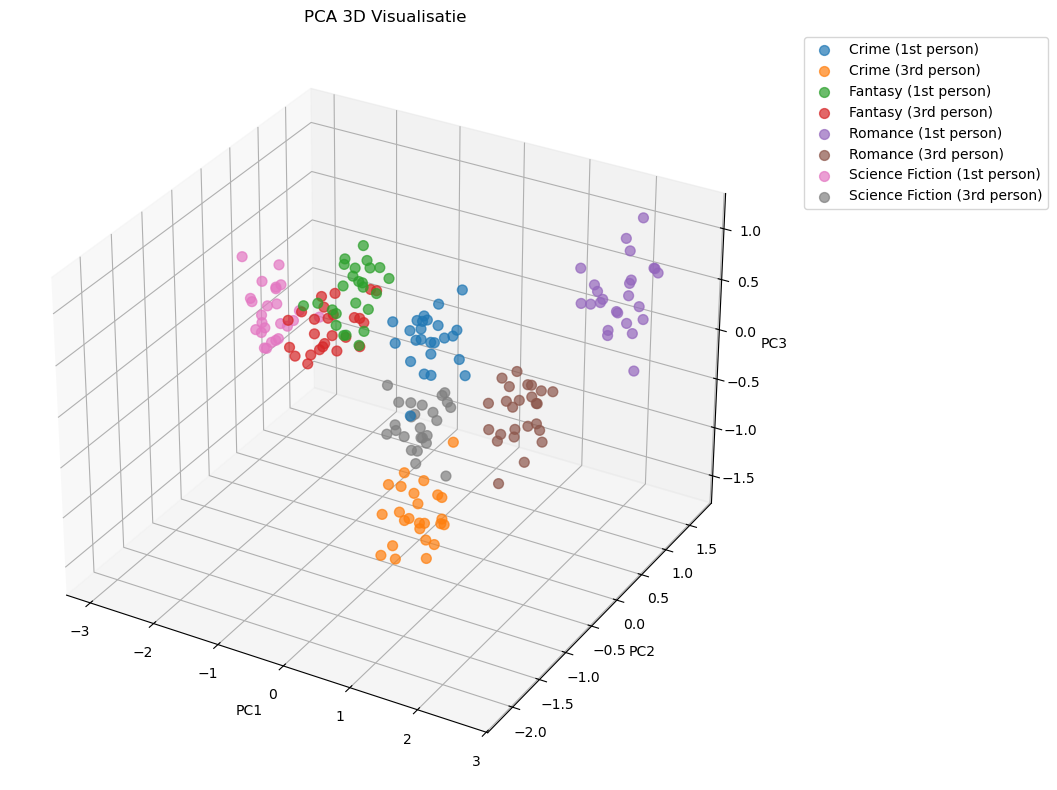

In [31]:
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

for categorie in np.unique(labels):
    mask = labels == categorie
    ax.scatter(X_3d[mask, 0], X_3d[mask, 1], X_3d[mask, 2], label=categorie, alpha=0.7, s=50)

ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_zlabel('PC3')
ax.set_title('PCA 3D Visualisatie')
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

### Opdracht 3. Analyse

Analyseer de resultaten:
1. Welke categorieën zijn op basis van de PCA-reductie te onderscheiden, en welke niet? 
2. Geef aan hoeveel procent van de informatie bewaard is gebleven in 2D en 3D respectievelijk.
3. Hoeveel dimensies zijn nodig om 90% van de informatie te bewaren?
4. En voor 95%?

1:
Science fiction 1st person, romance 1st person en crime 3rd person zijn goed te onderscheiden. We kunnen voor allemaal zien dat ze duidelijk een aparte cluster hebben. 

Voor Fantasy 1st en 3rd person, science fiction 3rd person, crime 1st person en Romance 3rd person is dit moeilijker te onderscheiden die hebben meer overlap met elkaar

2:
Voor 2d is er 68.67% behouden en voor 3d is er 77% behouden

3:
7 dimensies zijn nodig om 90% van de informatie te bewaren.

4:
11 dimensies zijn nodig om 95% van de informatie te bewaren.

In [35]:
feature_columns = [col for col in data.columns if col != 'label']
X = data.select(feature_columns).to_numpy()

arr = np.array(X)
gemiddelden = np.mean(arr, axis=0)
arr_gecentreerd = arr - gemiddelden

cov_matrix = np.cov(arr_gecentreerd, rowvar=False)

eigenvalues, eigenvectors = np.linalg.eigh(cov_matrix)

gesorteerde_indices = np.flip(np.argsort(eigenvalues))
eigenvalues = eigenvalues[gesorteerde_indices]

totale_variantie = np.sum(eigenvalues)
verklaarde_variantie_per_pc = eigenvalues / totale_variantie * 100
cumulatieve_variantie = np.cumsum(verklaarde_variantie_per_pc)

print(f"2D behoudt: {cumulatieve_variantie[1]:.2f}%")
print(f"3D behoudt: {cumulatieve_variantie[2]:.2f}%")
print(f"Dimensies voor 90%: {np.argmax(cumulatieve_variantie >= 90) + 1}")
print(f"Dimensies voor 95%: {np.argmax(cumulatieve_variantie >= 95) + 1}")

2D behoudt: 68.67%
3D behoudt: 77.22%
Dimensies voor 90%: 7
Dimensies voor 95%: 11


## Deel II: t-Distributed Stochastic Neighbour Embedding (t-SNE)

Een alternatieve methode voor dimensiereductie is _t-Distributed Stochastic Neighbour Embedding_ (t-SNE). 

### Opdracht 4. Toepassing
Gebruik SciKit-Learn om met behulp van t-SNE de data tot 2 dimensies te reduceren en plot het resultaat (wederom met kleuren voor de categorien). 

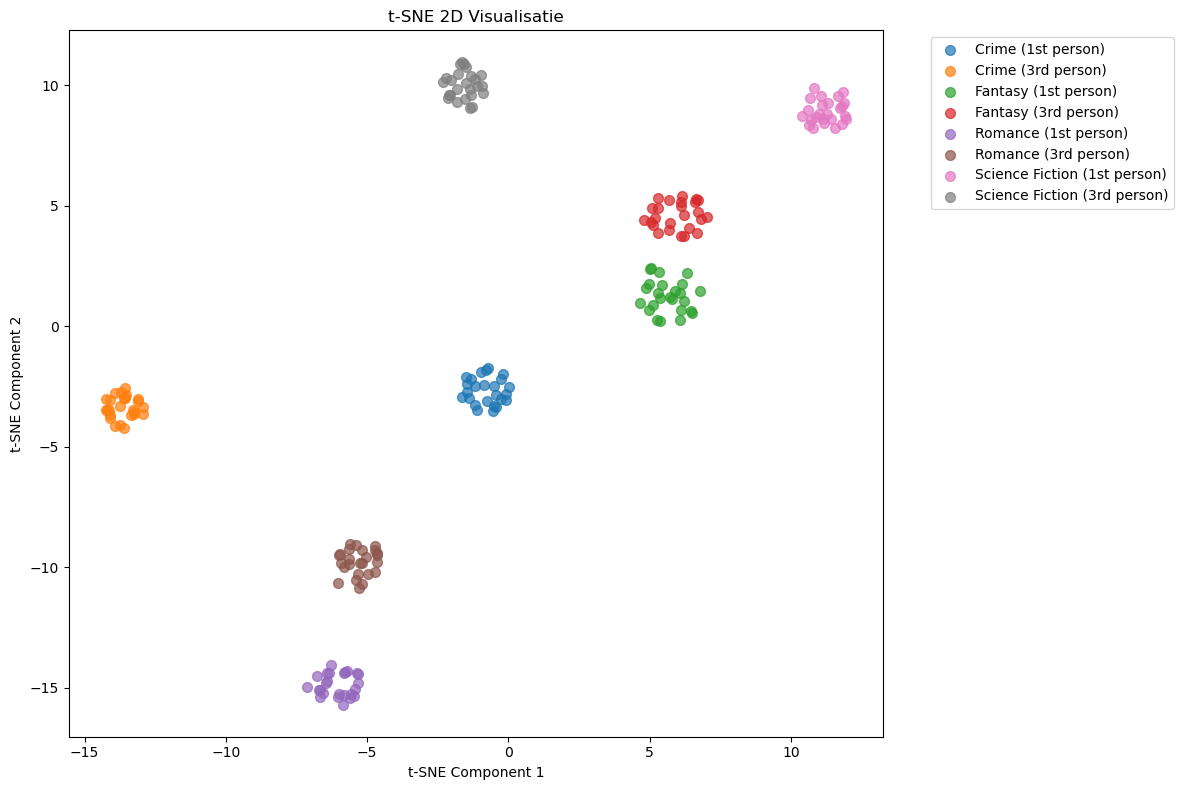

In [36]:
from sklearn.manifold import TSNE

feature_columns = [col for col in data.columns if col != 'label']
X = data.select(feature_columns).to_numpy()
labels = data['label'].to_numpy()

tsne = TSNE(n_components=2, random_state=42)
X_tsne = tsne.fit_transform(X)

plt.figure(figsize=(12, 8))

for categorie in np.unique(labels):
    mask = labels == categorie
    plt.scatter(X_tsne[mask, 0], X_tsne[mask, 1], label=categorie, alpha=0.7, s=50)

plt.xlabel('t-SNE Component 1')
plt.ylabel('t-SNE Component 2')
plt.title('t-SNE 2D Visualisatie')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

### Opdracht 5. Vergelijking

Vergelijk deze met de resultaten van je PCA-implementatie:

1. Hoe verhoudt de zichtbaarheid van de categorieën zich tussen beide resultaten?
2. Hoe verhouden de algoritmes zich in het behoud van informatie?

Beantwoord de volgende vragen los van de data van deze opdracht:

3. Waarvoor zou je PCA en t-SNE inzetten als je te maken krijgt met een onbekende (mogelijk ongelabelde) dataset?
4. Geef een voorbeeld waar PCA de voorkeur heeft boven t-SNE.
5. Geef een voorbeeld waar t-SNE de voorkeur heeft boven PCA.

1:
Bij t-SNE is het duidelijk te zien dat de clusters mooier vormen. Bij de pca was er nog veel overlap

2:
PCA behoudt meetbare informatie t-SNE behoudt geen meetbare globale informatie, maar focust op lokale structuur

3:
PCA helpt je begrijpen welke variabelen de meeste impact hebben en of er sprake is van ruis
t-SNE helpt je clusters zien die niet lineair zijn. Het is ideaal om te zien welke datapunten al groepen vormen.

4:
Voor als je een dataset hebt met bijvoorbeeld 50 features en je wil een classificatie model trainen. Dan is PCA beter want je kunt bepalen hoeveel features er nodig zijn

5: 
Wanneer je afbeeldingen wilt visualiseren, zoals handgeschreven cijfers. t-SNE toont dan duidelijke clusters per cijfer, omdat het non-lineaire relaties kan vangen die PCA mist.

### Opdracht 6. Project

Als het goed is, heb je op dit moment een eerste idee van de data waar je in het project mee gaat werken. Geef antwoord op onderstaande vragen.

1. Wat is de dimensionaliteit waar je mee te maken hebt?
2. Beschrijf hoe dimensionaliteitsreductie-algoritmen je kunnen helpen de data te verkennen.

1. Omdat ik met satellietbeelden ga werken is dit erg moeilijk om precies te zeggen, aangezien het bestand meer dan 1.5TB is. Wat ik wel weet is dat elke pixel meerdere kleur waardes heeft bijvoorbeeld RGB die heeft er 3. Stel we gaan ervan uit dat de resolutie 256x256 is met de kleurwaardes dan is dat 256x256x3 = 196608

2:
Met 1.5TB aan data is dimensionaliteitsreductie erg belangrijk:

PCA kan helpen om:
- De dataset te verkleinen zodat modellen sneller trainen
- Te bepalen hoeveel features echt nodig zijn
- Ruis in de satellietbeelden te verminderen

t-SNE kan helpen om:
- Een subset van beelden te visualiseren om clusters te ontdekken
- Te controleren of verschillende haventypes groeperen